In [ ]:
# Import Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Load Data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [5]:
import seaborn as sns

In [6]:
# Only get data analyst jobs in the US
# Only get data analyst jobs and US jobs
df_DA_US = df[(df["job_title_short"] == "Data Analyst") & (df["job_country"] == "United States")].copy()

# Drop NAN values from salary_year_avg for plotting
df_DA_US = df_DA_US.dropna(subset=["salary_year_avg"]) 

In [7]:
df_DA_US = df_DA_US.explode("job_skills")

In [8]:
df_DA_US_group = df_DA_US.groupby("job_skills")["salary_year_avg"].agg(["count", "median"])

df_DA_top_pay = df_DA_US_group.sort_values(by="median", ascending=False).head(10)

df_DA_skills = df_DA_US_group.sort_values(by="count", ascending=False).head(10).sort_values(by="median", ascending=False).head(10)

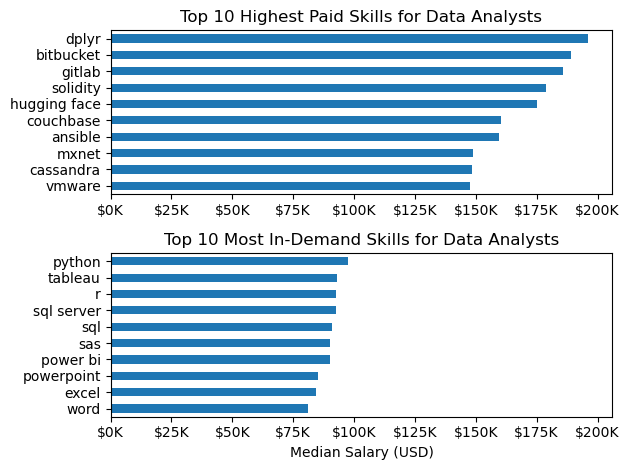

In [9]:
fig, ax = plt.subplots(2, 1)

df_DA_top_pay[::-1].plot(kind="barh", y="median", ax=ax[0], legend=False) # df_Da_top_pay[::-1] inverts the df
# ax[0].invert_yaxis() # invert the plot
ax[0].set_title("Top 10 Highest Paid Skills for Data Analysts")
ax[0].set_ylabel("")
ax[0].set_xlabel("")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${int(x/1000)}K"))

df_DA_skills[::-1].plot(kind="barh", y="median", ax=ax[1], legend=False)
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title("Top 10 Most In-Demand Skills for Data Analysts")
ax[1].set_ylabel("")
ax[1].set_xlabel("Median Salary (USD)")
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${int(x/1000)}K"))

fig.tight_layout()
plt.show()

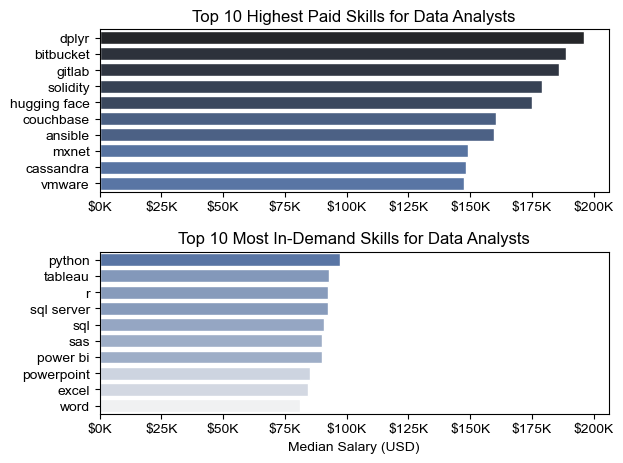

In [16]:
fig, ax = plt.subplots(2, 1)

# Set theme
sns.set_theme(style="ticks")

# Top 10 Highest Skills for Data Analysts
sns.barplot(data=df_DA_top_pay, x="median", y=df_DA_top_pay.index, ax=ax[0], hue="median", palette="dark:b_r", legend=False)
# ax[0].legend().remove() # remove the legend

# df_DA_top_pay[::-1].plot(kind="barh", y="median", ax=ax[0], legend=False) # df_Da_top_pay[::-1] inverts the df
# ax[0].invert_yaxis() # invert the plot
ax[0].set_title("Top 10 Highest Paid Skills for Data Analysts")
ax[0].set_ylabel("")
ax[0].set_xlabel("")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${int(x/1000)}K"))


# Top 10 Most In-Demand Skills for Data Analysts
sns.barplot(data=df_DA_skills, x="median", y=df_DA_skills.index, ax=ax[1], hue="median", palette="light:b", legend=False)
# ax[0].legend().remove() # remove the legend

# df_DA_skills[::-1].plot(kind="barh", y="median", ax=ax[1], legend=False)
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title("Top 10 Most In-Demand Skills for Data Analysts")
ax[1].set_ylabel("")
ax[1].set_xlabel("Median Salary (USD)")
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${int(x/1000)}K"))

fig.tight_layout()
plt.show()

### Histograms

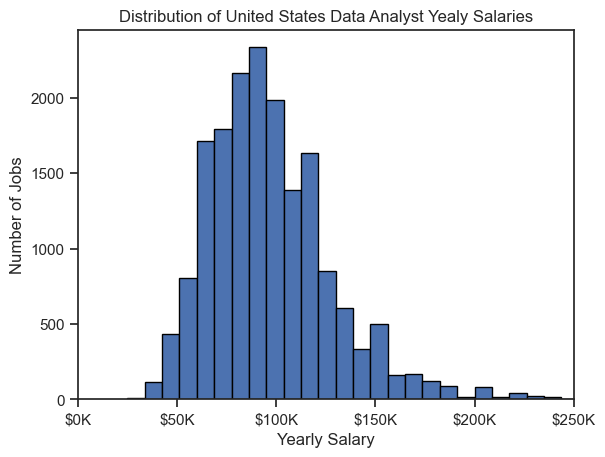

In [17]:
df_DA_US["salary_year_avg"].plot(kind="hist", bins=40, edgecolor="black")
plt.xlim(0, 250000)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${int(x/1000)}K"))

plt.title("Distribution of United States Data Analyst Yealy Salaries")
plt.xlabel("Yearly Salary")
plt.ylabel("Number of Jobs")
plt.show()

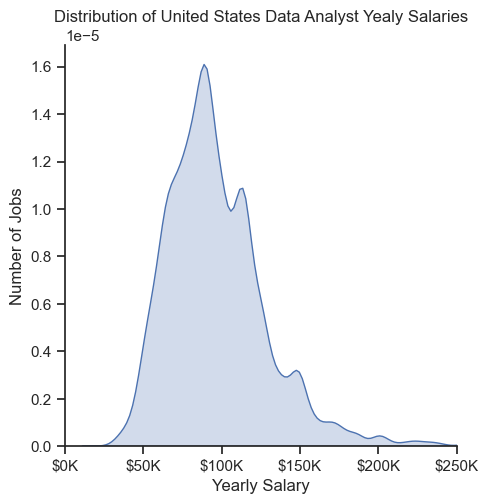

In [20]:
sns.displot(df_DA_US["salary_year_avg"], kind="kde", fill=True)
plt.xlim(0, 250000)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${int(x/1000)}K"))

plt.title("Distribution of United States Data Analyst Yealy Salaries")
plt.xlabel("Yearly Salary")
plt.ylabel("Number of Jobs")
plt.show()

### Box plots

C:\Users\dell\AppData\Local\Temp\ipykernel_1224\3568655172.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  job_list = [df_US[df["job_title_short"] == job_title]["salary_year_avg"] for job_title in job_titles]
C:\Users\dell\AppData\Local\Temp\ipykernel_1224\3568655172.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  job_list = [df_US[df["job_title_short"] == job_title]["salary_year_avg"] for job_title in job_titles]
C:\Users\dell\AppData\Local\Temp\ipykernel_1224\3568655172.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  job_list = [df_US[df["job_title_short"] == job_title]["salary_year_avg"] for job_title in job_titles]
C:\Users\dell\AppData\Local\Temp\ipykernel_1224\3568655172.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels

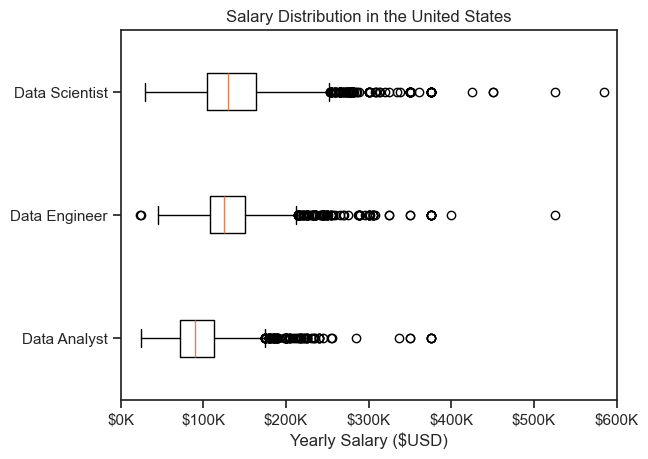

In [21]:
job_titles = ["Data Analyst", "Data Engineer", "Data Scientist"]

# Filter the data to approriate job_titles
df_US = df[(df["job_title_short"].isin(job_titles)) & (df["job_country"] == "United States")].copy()
df_US = df_US.dropna(subset=["salary_year_avg"])

job_list = [df_US[df["job_title_short"] == job_title]["salary_year_avg"] for job_title in job_titles]

ax =plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${int(x/1000)}K"))
plt.xlim(0, 600000)

plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title("Salary Distribution in the United States")
plt.xlabel("Yearly Salary ($USD)")
plt.show()

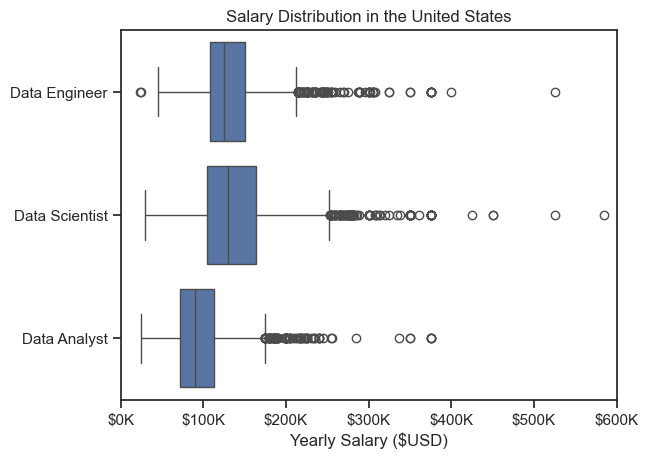

In [29]:
sns.boxplot(data=df_US, x="salary_year_avg", y="job_title_short")

ax =plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${int(x/1000)}K"))

plt.title("Salary Distribution in the United States")
plt.ylabel("")
plt.xlabel("Yearly Salary ($USD)")
plt.xlim(0, 600000)


plt.show()